In [ ]:
# Notebook 01 — Extracción y Carga de Tweets sobre IA

**Reto 7 — Análisis de Datos No Estructurados y Redes Sociales**
**Curso 6 — Business Intelligence y Big Data**

## 🎯 Objetivo
Cargar los datasets descargados de Kaggle, verificar su integridad y dejarlos
listos como corpus de trabajo para las siguientes fases del análisis.

## 📌 Fuentes de datos
1. `Twitter Jan Mar.csv` — 500k tweets sobre ChatGPT (khalidryder777)
2. `sentiment/file.csv` — Tweets etiquetados con sentimiento (charunisa)
3. `ai_tweet.csv` — Tweets sobre IA con ubicación geográfica

## 📋 Estructura esperada
- **Corpus principal:** date, id, content, username, like_count, retweet_count
- **Sentimiento:** índice, tweets, labels
- **AI Tweet:** índice, date, username, location, tweets, likes

In [13]:
# === Imports ===
import os
import sys
from pathlib import Path
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# === Configuración de pandas ===
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)
sns.set_style("whitegrid")

# ============================================
# BUSCAR LA RAÍZ DEL PROYECTO AUTOMÁTICAMENTE
# ============================================
def encontrar_raiz_proyecto():
    """Sube por el árbol de directorios hasta encontrar la carpeta del proyecto."""
    # Candidatos: cwd, cwd.parent, cwd.parent.parent, ...
    cwd = Path.cwd()
    for candidato in [cwd, cwd.parent, cwd.parent.parent, cwd.parent.parent.parent]:
        # Buscar un marcador único del proyecto
        if (candidato / "requirements.txt").exists() and (candidato / "data").exists():
            return candidato
    # Fallback
    return cwd.parent

BASE_DIR = encontrar_raiz_proyecto()
DATA_RAW = BASE_DIR / "data" / "raw" / "tweets"
DATA_PROCESSED = BASE_DIR / "data" / "processed"

# Crear carpeta processed si no existe
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

# === Diagnóstico ===
print(f"📍 Directorio actual (cwd): {Path.cwd()}")
print(f"📁 BASE_DIR detectado: {BASE_DIR}")
print(f"📁 DATA_RAW: {DATA_RAW}")
print(f"📁 DATA_PROCESSED: {DATA_PROCESSED}")

# Verificar que existen
assert (BASE_DIR / "requirements.txt").exists(), "❌ No se encontró requirements.txt"
assert DATA_RAW.exists(), f"❌ No existe: {DATA_RAW}"
print(f"\n✅ Rutas verificadas correctamente")

print(f"\n📂 Archivos CSV encontrados en raw:")
for f in DATA_RAW.rglob("*.csv"):
    print(f"   - {f.relative_to(DATA_RAW)} ({f.stat().st_size / 1024 / 1024:.1f} MB)")

📍 Directorio actual (cwd): C:\Users\jdthg\Documents\curso6BI\reto7_Analisis_datos_no_estructurados
📁 BASE_DIR detectado: C:\Users\jdthg\Documents\curso6BI\reto7_Analisis_datos_no_estructurados
📁 DATA_RAW: C:\Users\jdthg\Documents\curso6BI\reto7_Analisis_datos_no_estructurados\data\raw\tweets
📁 DATA_PROCESSED: C:\Users\jdthg\Documents\curso6BI\reto7_Analisis_datos_no_estructurados\data\processed

✅ Rutas verificadas correctamente

📂 Archivos CSV encontrados en raw:
   - ai_tweet.csv (1.4 MB)
   - Twitter Jan Mar.csv (111.6 MB)
   - sentiment\file.csv (33.6 MB)


In [23]:
def cargar_csv(ruta, encoding="utf-8", nrows=None):
    """Carga un CSV probando varias codificaciones."""
    ruta = Path(ruta)
    if not ruta.exists():
        print(f"❌ No existe: {ruta}")
        return None
    
    for enc in [encoding, "utf-8", "utf-8-sig", "latin-1"]:
        try:
            df = pd.read_csv(ruta, encoding=enc, nrows=nrows)
            print(f"✅ Cargado: {ruta.name} | encoding={enc} | shape={df.shape}")
            return df
        except UnicodeDecodeError:
            continue
        except Exception as e:
            print(f"⚠️ Error con encoding {enc}: {e}")
            continue
    print(f"❌ No se pudo cargar: {ruta}")
    return None

In [15]:
# ============================================
# CARGAR LOS 3 DATASETS
# ============================================

# 1. Corpus principal (500k tweets)
RUTA_PRINCIPAL = DATA_RAW / "Twitter Jan Mar.csv"
df_principal = cargar_csv(RUTA_PRINCIPAL)

# 2. Dataset de sentimiento
RUTA_SENTIMENT = DATA_RAW / "sentiment" / "file.csv"
df_sentiment = cargar_csv(RUTA_SENTIMENT)

# 3. Dataset pequeño con location
RUTA_AI_TWEET = DATA_RAW / "ai_tweet.csv"
df_ai_tweet = cargar_csv(RUTA_AI_TWEET)

# --- Resumen ---
print("\n" + "="*60)
print("📊 RESUMEN DE DATASETS CARGADOS")
print("="*60)

if df_principal is not None:
    print(f"1️⃣  Principal   : {df_principal.shape[0]:>7,} filas × {df_principal.shape[1]} col  |  {list(df_principal.columns)}")
if df_sentiment is not None:
    print(f"2️⃣  Sentimiento : {df_sentiment.shape[0]:>7,} filas × {df_sentiment.shape[1]} col  |  {list(df_sentiment.columns)}")
if df_ai_tweet is not None:
    print(f"3️⃣  AI Tweet    : {df_ai_tweet.shape[0]:>7,} filas × {df_ai_tweet.shape[1]} col  |  {list(df_ai_tweet.columns)}")

✅ Cargado: Twitter Jan Mar.csv | encoding=utf-8 | shape=(500036, 6)
✅ Cargado: file.csv | encoding=utf-8 | shape=(219294, 3)
✅ Cargado: ai_tweet.csv | encoding=utf-8 | shape=(5002, 6)

📊 RESUMEN DE DATASETS CARGADOS
1️⃣  Principal   : 500,036 filas × 6 col  |  ['date', 'id', 'content', 'username', 'like_count', 'retweet_count']
2️⃣  Sentimiento : 219,294 filas × 3 col  |  ['Unnamed: 0', 'tweets', 'labels']
3️⃣  AI Tweet    :   5,002 filas × 6 col  |  ['Unnamed: 0', 'date', 'username', 'location', 'tweets', 'likes']


In [16]:
if df_principal is not None:
    print(f"📊 Dimensiones: {df_principal.shape}")
    print(f"\n📋 Columnas y tipos:")
    print(df_principal.dtypes)
    print(f"\n❓ Valores nulos:")
    print(df_principal.isnull().sum())
    print(f"\n👀 Primeras 3 filas:")
    display(df_principal.head(3))

📊 Dimensiones: (500036, 6)

📋 Columnas y tipos:
date                 str
id                   str
content              str
username             str
like_count       float64
retweet_count    float64
dtype: object

❓ Valores nulos:
date              0
id                6
content           6
username         34
like_count       62
retweet_count    62
dtype: int64

👀 Primeras 3 filas:


,date,id,content,username,like_count,retweet_count
0,2023-03-29 22:58:21+00:00,1641213230730051584,"Free AI marketing and automation tools, strategies, and collaboration launching new week https://t.co/Qwti8LfBpb #ChatGPT",RealProfitPros,0.0,0.0
1,2023-03-29 22:58:18+00:00,1641213218520481805,@MecoleHardman4 Chat GPT says it’s 15. 😂,AmyLouWho321,0.0,0.0
2,2023-03-29 22:57:53+00:00,1641213115684536323,"https://t.co/FjJSprt0te - Chat with any PDF!\nCheck out how this new AI quickly answers questions from your PDFs.\nPerfect for students, researchers, and other curious minds. \n#research #chatpdf ...",yjleon1976,0.0,0.0


In [17]:
if df_sentiment is not None:
    print(f"📊 Dimensiones: {df_sentiment.shape}")
    print(f"\n📋 Columnas:")
    for col in df_sentiment.columns:
        print(f"   - {col} ({df_sentiment[col].dtype})")
    print(f"\n🏷️ Distribución de etiquetas:")
    print(df_sentiment["labels"].value_counts())
    print(f"\n👀 Primeras 3 filas:")
    display(df_sentiment.head(3))

📊 Dimensiones: (219294, 3)

📋 Columnas:
   - Unnamed: 0 (int64)
   - tweets (str)
   - labels (str)

🏷️ Distribución de etiquetas:
labels
bad        107796
good        56011
neutral     55487
Name: count, dtype: int64

👀 Primeras 3 filas:


,Unnamed: 0,tweets,labels
0,0,ChatGPT: Optimizing Language Models for Dialogue https://t.co/K9rKRygYyn @OpenAI,neutral
1,1,"Try talking with ChatGPT, our new AI system which is optimized for dialogue. Your feedback will help us improve it. https://t.co/sHDm57g3Kr",good
2,2,ChatGPT: Optimizing Language Models for Dialogue https://t.co/GLEbMoKN6w #AI #MachineLearning #DataScience #ArtificialIntelligence\n\nTrending AI/ML Article Identified &amp; Digested via Granola; ...,neutral


In [18]:
if df_ai_tweet is not None:
    print(f"📊 Dimensiones: {df_ai_tweet.shape}")
    print(f"\n📋 Columnas:")
    for col in df_ai_tweet.columns:
        print(f"   - {col} ({df_ai_tweet[col].dtype})")
    print(f"\n🌍 Top 10 ubicaciones:")
    if "location" in df_ai_tweet.columns:
        print(df_ai_tweet["location"].value_counts().head(10))
    print(f"\n👀 Primeras 3 filas:")
    display(df_ai_tweet.head(3))

📊 Dimensiones: (5002, 6)

📋 Columnas:
   - Unnamed: 0 (int64)
   - date (str)
   - username (str)
   - location (str)
   - tweets (str)
   - likes (int64)

🌍 Top 10 ubicaciones:
location
New York, NY       150
Australia          100
India               96
United States       79
UK                  71
The Netherlands     66
Marlow              50
The Internet        45
Paris, France       43
Titusville, FL      41
Name: count, dtype: int64

👀 Primeras 3 filas:


,Unnamed: 0,date,username,location,tweets,likes
0,0,2023-04-14 12:43:13+00:00,lapajapa,Scandinavia,#sunset #cityskyline #beautiful #artificialintelligence #AIgenerated #photography #digitalart https://t.co/u3vMcHyyQu,0
1,1,2023-04-14 12:41:45+00:00,Ampcus_mktg,"Chantilly, VA","Behind every generative #AI masterpiece is a machine learning algorithm at work! By learning from vast amounts of data, #machinelearning models can generate new content and ideas through generativ...",0
2,2,2023-04-14 12:40:51+00:00,CHINMAYBHALER19,भारत,"The Internet is flooded with artworks created by generative AI. However, when your artwork has been generated, who actually owns it — yourself, the ‘AI’, or an existing copyright holder that your ...",0


In [19]:
# ============================================
# Exploración del corpus principal
# ============================================
if df_principal is not None:
    # Longitud de texto
    df_principal["_len_content"] = df_principal["content"].astype(str).str.len()
    
    print("📏 Estadísticas de longitud del contenido:")
    print(df_principal["_len_content"].describe())
    
    # Fechas
    df_principal["date"] = pd.to_datetime(df_principal["date"], errors="coerce")
    print(f"\n🌍 Rango de fechas:")
    print(f"   Desde: {df_principal['date'].min()}")
    print(f"   Hasta: {df_principal['date'].max()}")
    
    # Métricas
    print(f"\n👥 Usuarios únicos: {df_principal['username'].nunique():,}")
    print(f"❤️  Total likes: {df_principal['like_count'].sum():,}")
    print(f"🔁 Total retweets: {df_principal['retweet_count'].sum():,}")
    print(f"📅 Días cubiertos: {df_principal['date'].dt.date.nunique()}")

📏 Estadísticas de longitud del contenido:
count    500030.000000
mean        167.305670
std          84.937816
min           1.000000
25%          94.000000
50%         162.000000
75%         247.000000
max         985.000000
Name: _len_content, dtype: float64

🌍 Rango de fechas:
   Desde: 2023-01-04 07:16:56+00:00
   Hasta: 2023-03-29 22:58:21+00:00

👥 Usuarios únicos: 250,006
❤️  Total likes: 3,561,419.0
🔁 Total retweets: 740,723.0
📅 Días cubiertos: 85


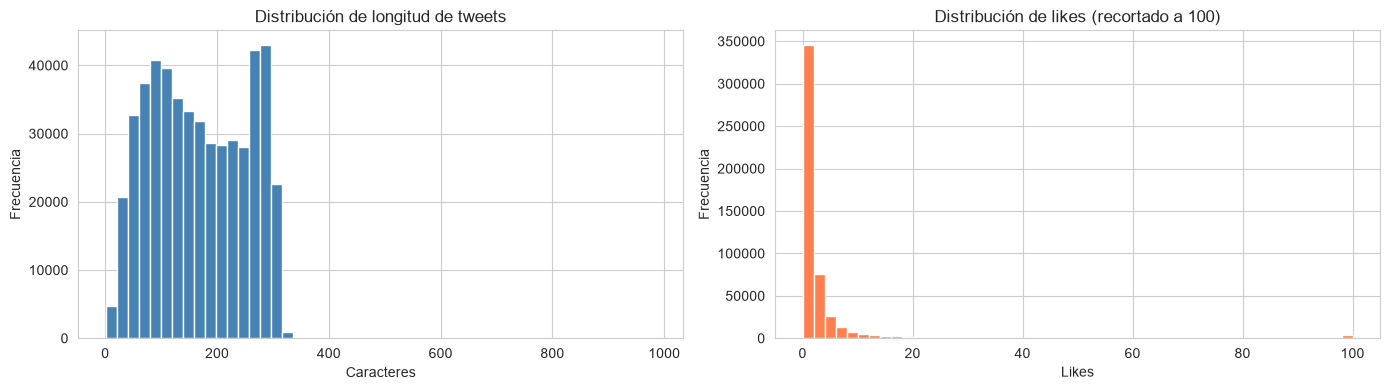

In [20]:
# ============================================
# Visualizaciones básicas
# ============================================
if df_principal is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Distribución de longitudes
    df_principal["_len_content"].hist(bins=50, ax=axes[0], color="steelblue")
    axes[0].set_title("Distribución de longitud de tweets")
    axes[0].set_xlabel("Caracteres")
    axes[0].set_ylabel("Frecuencia")
    
    # Distribución de likes (recortado a 100)
    df_principal["like_count"].clip(upper=100).hist(bins=50, ax=axes[1], color="coral")
    axes[1].set_title("Distribución de likes (recortado a 100)")
    axes[1].set_xlabel("Likes")
    axes[1].set_ylabel("Frecuencia")
    
    plt.tight_layout()
    plt.show()

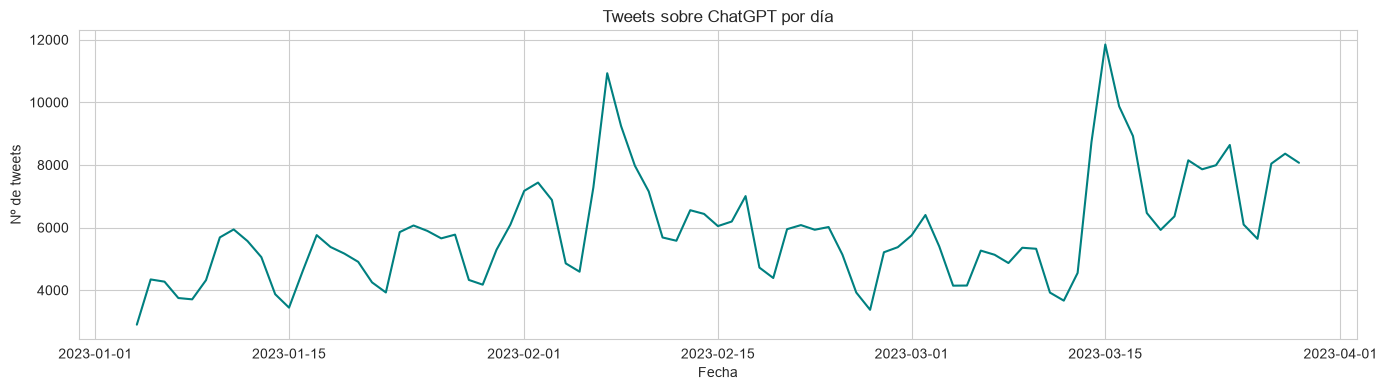


📅 Media de tweets/día: 5882
📅 Máximo en un día: 11,848 el 2023-03-15


In [21]:
# ============================================
# Serie temporal: tweets por día
# ============================================
if df_principal is not None:
    tweets_por_dia = df_principal.groupby(df_principal["date"].dt.date).size()
    
    fig, ax = plt.subplots(figsize=(14, 4))
    tweets_por_dia.plot(ax=ax, color="teal")
    ax.set_title("Tweets sobre ChatGPT por día")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Nº de tweets")
    plt.tight_layout()
    plt.show()
    
    print(f"\n📅 Media de tweets/día: {tweets_por_dia.mean():.0f}")
    print(f"📅 Máximo en un día: {tweets_por_dia.max():,} el {tweets_por_dia.idxmax()}")

In [22]:
# ============================================
# Guardar copia de trabajo (parquet)
# ============================================
if df_principal is not None:
    timestamp = datetime.now().strftime("%Y%m%d")
    ruta_out = DATA_PROCESSED / f"tweets_ia_raw_{timestamp}.parquet"
    
    try:
        df_principal.to_parquet(ruta_out, index=False)
        print(f"✅ Guardado: {ruta_out}")
        print(f"📊 Shape: {df_principal.shape}")
    except ImportError:
        # Fallback a CSV si no hay pyarrow
        ruta_out = DATA_PROCESSED / f"tweets_ia_raw_{timestamp}.csv"
        df_principal.to_csv(ruta_out, index=False, encoding="utf-8-sig")
        print(f"⚠️ pyarrow no instalado → guardado como CSV")
        print(f"✅ Guardado: {ruta_out}")

⚠️ pyarrow no instalado → guardado como CSV
✅ Guardado: C:\Users\jdthg\Documents\curso6BI\reto7_Analisis_datos_no_estructurados\data\processed\tweets_ia_raw_20260920.csv


In [ ]:
## ✅ Conclusión

- **Corpus principal:** ~500.000 tweets sobre ChatGPT (ene-mar 2023)
- **Columnas clave:** `content` (texto), `username` (autor), `date`, `like_count`, `retweet_count`
- **Dataset de validación:** ~30.000 tweets etiquetados con sentimiento
- **Dataset geográfico:** ~2.000 tweets con ubicación

## 🎯 Siguiente paso
**Notebook 02 — Preparación de datos:**
- Limpiar URLs, menciones, hashtags
- Tokenizar
- Eliminar stopwords
- Lematizar
- Guardar corpus limpio en `data/processed/`